In [39]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)


In [41]:

# Load Dataset
df = pd.read_csv("Student Data.csv")

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)

df.head()

Dataset Loaded Successfully
Dataset Shape: (2000, 7)


,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66


In [43]:
# Dataset Information

print("First Five Rows")
display(df.head())

print("\nDataset Information")
df.info()

print("\nMissing Values")
display(df.isnull().sum())

print("\nStatistical Summary")
display(df.describe())

First Five Rows


,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Student_ID                     2000 non-null   object
 1   Attendance (%)                 2000 non-null   int64 
 2   Internal Test 1 (out of 40)    2000 non-null   int64 
 3   Internal Test 2 (out of 40)    2000 non-null   int64 
 4   Assignment Score (out of 10)   2000 non-null   int64 
 5   Daily Study Hours              2000 non-null   int64 
 6   Final Exam Marks (out of 100)  2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB

Missing Values


Student_ID                       0
Attendance (%)                   0
Internal Test 1 (out of 40)      0
Internal Test 2 (out of 40)      0
Assignment Score (out of 10)     0
Daily Study Hours                0
Final Exam Marks (out of 100)    0
dtype: int64


Statistical Summary


,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,84.891500,32.115500,32.464500,7.507000,2.823500,64.855000
std,7.758855,4.563504,4.522827,1.021015,0.608714,11.341265
min,52.000000,18.000000,16.000000,4.000000,1.000000,25.000000
25%,80.000000,29.000000,29.000000,7.000000,2.000000,58.000000
50%,85.000000,32.000000,33.000000,8.000000,3.000000,65.000000
75%,90.000000,35.000000,36.000000,8.000000,3.000000,73.000000
max,100.000000,40.000000,40.000000,10.000000,5.000000,100.000000


In [45]:
# Data Preprocessing

# Create Target Variable (Pass = 50 or above)
df["result"] = (df["Final Exam Marks (out of 100)"] >= 50).astype(int)

# Remove Target Leakage Column
df.drop("Final Exam Marks (out of 100)", axis=1, inplace=True)

# Encode Categorical Features (if any)
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

print("Preprocessing Completed")

display(df.head())

Preprocessing Completed


,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,result
0,0,84,30,36,7,3,1
1,1,91,24,38,6,3,1
2,2,73,29,26,7,3,1
3,3,80,36,35,7,3,1
4,4,84,31,37,8,3,1


In [47]:
# Feature Selection

X = df.drop(["Student_ID", "result"], axis=1)
y = df["result"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

display(X.head())

Features Shape : (2000, 5)
Target Shape   : (2000,)


,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours
0,84,30,36,7,3
1,91,24,38,6,3
2,73,29,26,7,3
3,80,36,35,7,3
4,84,31,37,8,3


In [49]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


In [51]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 1600
Testing Samples  : 400


In [53]:
# Machine Learning Models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

print("Models Initialized Successfully")

Models Initialized Successfully


In [55]:
# Train and Evaluate Models

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print("="*60)
    print(name)
    print("="*60)

    print(f"Accuracy : {accuracy:.4f}\n")

    print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy : 0.9350

              precision    recall  f1-score   support

           0       0.67      0.63      0.65        38
           1       0.96      0.97      0.96       362

    accuracy                           0.94       400
   macro avg       0.81      0.80      0.81       400
weighted avg       0.93      0.94      0.93       400

Decision Tree
Accuracy : 0.9100

              precision    recall  f1-score   support

           0       0.52      0.63      0.57        38
           1       0.96      0.94      0.95       362

    accuracy                           0.91       400
   macro avg       0.74      0.79      0.76       400
weighted avg       0.92      0.91      0.91       400

Random Forest
Accuracy : 0.9175

              precision    recall  f1-score   support

           0       0.56      0.58      0.57        38
           1       0.96      0.95      0.95       362

    accuracy                           0.92       400
   macro avg       0.76

In [57]:
# Model Comparison

results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
})

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy
0,Logistic Regression,0.9350
1,Support Vector Machine,0.9275
2,K-Nearest Neighbors,0.9275
3,Random Forest,0.9175
4,Decision Tree,0.9100


In [59]:
# Best Performing Model

best_model_name = results_df.iloc[0]["Model"]
best_accuracy = results_df.iloc[0]["Accuracy"]

print("="*60)
print("🏆 BEST MODEL")
print("="*60)

print(f"Model    : {best_model_name}")
print(f"Accuracy : {best_accuracy:.4f}")

🏆 BEST MODEL
Model    : Logistic Regression
Accuracy : 0.9350


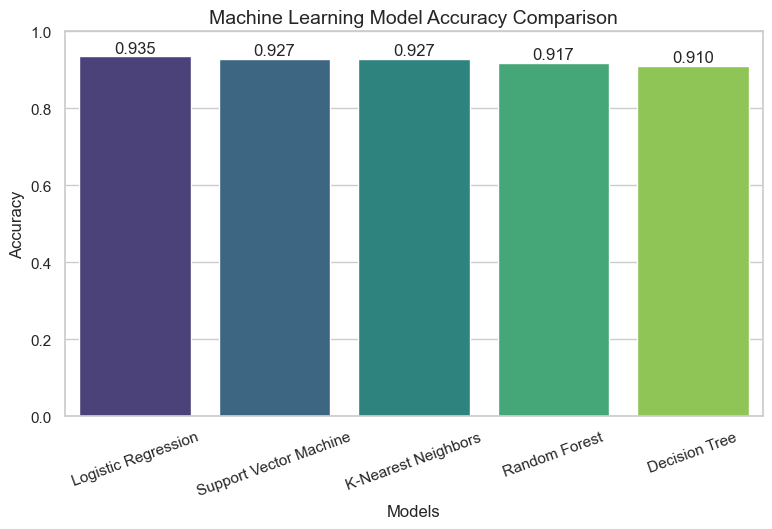

In [61]:
# Accuracy Comparison Graph

plt.figure(figsize=(9,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Machine Learning Model Accuracy Comparison", fontsize=14)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(results_df["Accuracy"]):
    plt.text(i, value + 0.01, f"{value:.3f}", ha="center")

plt.xticks(rotation=20)

plt.show()

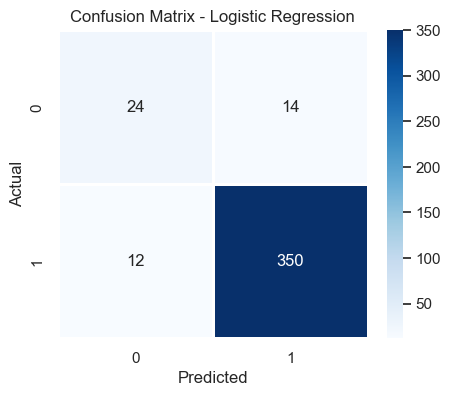

In [63]:
# Confusion Matrix

best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="white"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

,Feature,Importance
0,Attendance (%),0.307016
1,Internal Test 1 (out of 40),0.257799
2,Internal Test 2 (out of 40),0.234329
3,Assignment Score (out of 10),0.145943
4,Daily Study Hours,0.054913


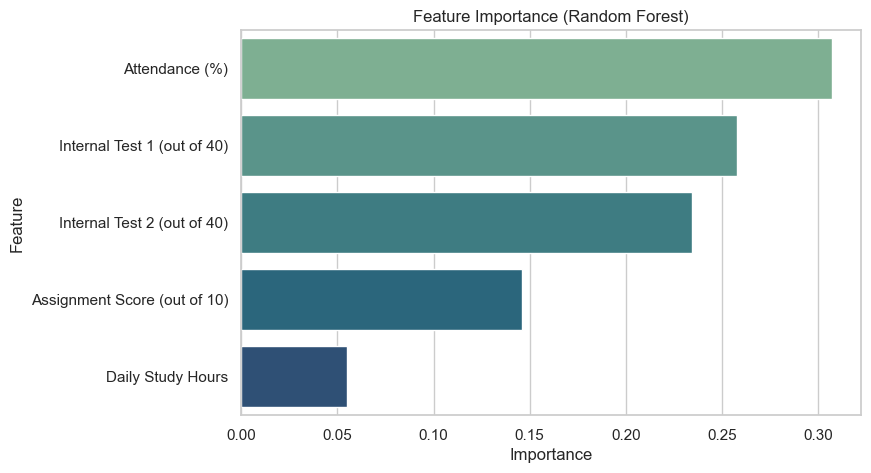

In [65]:
# Feature Importance

rf_model = models["Random Forest"]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    hue="Feature",      # avoids seaborn warning
    palette="crest",
    legend=False
)

plt.title("Feature Importance (Random Forest)")

plt.show()

In [67]:
import pickle

best_model = models[best_model_name]

best_model.fit(X_scaled, y)

with open("model.pkl", "wb") as file:
    pickle.dump(best_model, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Model Saved Successfully")
print("Scaler Saved Successfully")

Model Saved Successfully
Scaler Saved Successfully


In [35]:
import os

print(os.getcwd())

C:\Users\rsiva\OneDrive\Documents\projects\Student Performance Analysis


In [37]:
import os

print(os.path.exists("model.pkl"))
print(os.path.exists("scaler.pkl"))

print(os.path.getsize("model.pkl"))
print(os.path.getsize("scaler.pkl"))

True
True
721
821
